# 🎵 Music Genre Classification — Step 7: Experiment With Various Models

## Capstone: ML Engineering & AI Bootcamp

**Objective:** Build and compare multiple ML models for classifying music into 10 predefined genres using audio features extracted from the GTZAN dataset.

**Dataset:** [GTZAN Music Genre Dataset](https://huggingface.co/datasets/AntSanchez77/gtzan-music-genre-dataset) — 860 audio tracks (30s each), 10 genres, ~86 tracks per genre.

**Genres:** Blues, Classical, Country, Disco, Hip-Hop, Jazz, Metal, Pop, Reggae, Rock

---

### Pipeline Overview
1. **Data Loading** — Download GTZAN from Hugging Face
2. **Feature Extraction** — Extract audio features with librosa (MFCCs, spectral, rhythmic)
3. **Baseline Models** — Automated comparison of 7+ algorithms
4. **Performance Metrics** — Accuracy, F1 (macro), confusion matrices
5. **Hyperparameter Tuning** — GridSearchCV on top performers
6. **Cross-Validation** — Stratified K-Fold for robust evaluation
7. **Ensemble Methods** — VotingClassifier & StackingClassifier
8. **Overfitting Analysis** — Train vs. test performance gap
9. **Best Model Selection** — Final recommendation

## 1. Environment Setup & Dependencies

In [ ]:
# Install required packages (uncomment if needed)
# !pip install librosa datasets scikit-learn xgboost lightgbm matplotlib seaborn pandas numpy joblib tqdm

In [1]:
import os
import warnings
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa

from tqdm import tqdm
from datasets import load_dataset

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV,
    RandomizedSearchCV, cross_val_score, cross_validate
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, VotingClassifier, StackingClassifier,
    ExtraTreesClassifier
)
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All imports loaded successfully.')

All imports loaded successfully.


## 2. Load the GTZAN Dataset from Hugging Face

In [2]:
# Load the GTZAN dataset from Hugging Face
# This downloads ~1.2 GB of audio data on first run
print('Loading GTZAN dataset from Hugging Face...')
print('(This may take a few minutes on first download)')

ds = load_dataset('AntSanchez77/gtzan-music-genre-dataset', split='train')

print(f'\nDataset loaded: {len(ds)} samples')
print(f'Features: {ds.features}')
print(f'\nColumn names: {ds.column_names}')

Loading GTZAN dataset from Hugging Face...
(This may take a few minutes on first download)


README.md:   0%|          | 0.00/352 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/380M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/380M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/379M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/860 [00:00<?, ? examples/s]


Dataset loaded: 860 samples
Features: {'audio': Audio(sampling_rate=22050, decode=True, stream_index=None), 'genre': Value('string')}

Column names: ['audio', 'genre']


In [3]:
# Quick look at a sample
sample = ds[0]
print('Sample keys:', list(sample.keys()))
print('Genre:', sample.get('genre', sample.get('label', 'unknown')))

if 'audio' in sample:
    audio_info = sample['audio']
    print(f'Audio sampling rate: {audio_info["sampling_rate"]} Hz')
    print(f'Audio array length: {len(audio_info["array"])}')
    print(f'Duration: {len(audio_info["array"]) / audio_info["sampling_rate"]:.1f} seconds')

Sample keys: ['audio', 'genre']
Genre: blues
Audio sampling rate: 22050 Hz
Audio array length: 661794
Duration: 30.0 seconds


## 3. Audio Feature Extraction

We extract a comprehensive set of audio features using **librosa**. These features capture timbral, spectral, and rhythmic properties that are well-suited for genre classification with traditional ML:

| Feature Group | Features | Description |
|---|---|---|
| **Timbral** | 20 MFCCs (mean + std) | Mel-frequency cepstral coefficients — the gold standard for audio classification |
| **Spectral** | Centroid, Bandwidth, Rolloff, Contrast, Flatness | Shape of the frequency spectrum |
| **Rhythmic** | Tempo, Zero-Crossing Rate | Beat and temporal characteristics |
| **Harmonic** | Chroma (12 bins, mean + std), Tonnetz | Pitch class profiles |

In [4]:
def extract_features(audio_array, sr=22050):
    """
    Extract a comprehensive set of audio features from a waveform.

    Returns a dictionary of ~80+ features covering timbral, spectral,
    rhythmic, and harmonic characteristics.
    """
    y = np.array(audio_array, dtype=np.float32)
    features = {}

    try:
        # --- MFCCs (20 coefficients) ---
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
        for i in range(20):
            features[f'mfcc_{i+1}_mean'] = np.mean(mfccs[i])
            features[f'mfcc_{i+1}_std'] = np.std(mfccs[i])

        # --- Delta MFCCs (first derivative, captures dynamics) ---
        delta_mfccs = librosa.feature.delta(mfccs)
        for i in range(20):
            features[f'delta_mfcc_{i+1}_mean'] = np.mean(delta_mfccs[i])

        # --- Spectral Features ---
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
        features['spectral_centroid_mean'] = np.mean(spectral_centroid)
        features['spectral_centroid_std'] = np.std(spectral_centroid)

        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
        features['spectral_bandwidth_mean'] = np.mean(spectral_bandwidth)
        features['spectral_bandwidth_std'] = np.std(spectral_bandwidth)

        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
        features['spectral_rolloff_mean'] = np.mean(spectral_rolloff)
        features['spectral_rolloff_std'] = np.std(spectral_rolloff)

        spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        for i in range(spectral_contrast.shape[0]):
            features[f'spectral_contrast_{i+1}_mean'] = np.mean(spectral_contrast[i])

        spectral_flatness = librosa.feature.spectral_flatness(y=y)[0]
        features['spectral_flatness_mean'] = np.mean(spectral_flatness)
        features['spectral_flatness_std'] = np.std(spectral_flatness)

        # --- Zero-Crossing Rate ---
        zcr = librosa.feature.zero_crossing_rate(y)[0]
        features['zcr_mean'] = np.mean(zcr)
        features['zcr_std'] = np.std(zcr)

        # --- RMS Energy ---
        rms = librosa.feature.rms(y=y)[0]
        features['rms_mean'] = np.mean(rms)
        features['rms_std'] = np.std(rms)

        # --- Tempo ---
        tempo = librosa.feature.tempo(y=y, sr=sr)
        features['tempo'] = tempo[0] if len(tempo) > 0 else 0.0

        # --- Chroma Features (12 pitch classes) ---
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        for i in range(12):
            features[f'chroma_{i+1}_mean'] = np.mean(chroma[i])
            features[f'chroma_{i+1}_std'] = np.std(chroma[i])

        # --- Tonnetz (tonal centroid) ---
        y_harmonic = librosa.effects.harmonic(y)
        tonnetz = librosa.feature.tonnetz(y=y_harmonic, sr=sr)
        for i in range(6):
            features[f'tonnetz_{i+1}_mean'] = np.mean(tonnetz[i])

    except Exception as e:
        print(f'  Error extracting features: {e}')
        return None

    return features

print(f'Feature extractor defined — extracts ~{len(extract_features(np.random.randn(22050*5), 22050))} features per track')

Feature extractor defined — extracts ~110 features per track


In [5]:
# Extract features from all tracks
# This takes ~10-20 minutes depending on your hardware

FEATURES_CACHE = 'gtzan_features.csv'

if os.path.exists(FEATURES_CACHE):
    print(f'Loading cached features from {FEATURES_CACHE}...')
    df = pd.read_csv(FEATURES_CACHE)
    print(f'Loaded {len(df)} samples with {len(df.columns) - 1} features')
else:
    print('Extracting features from audio tracks...')
    records = []
    errors = []

    for idx in tqdm(range(len(ds)), desc='Extracting features'):
        sample = ds[idx]
        audio = sample['audio']
        y = np.array(audio['array'], dtype=np.float32)
        sr = audio['sampling_rate']

        # Get genre label
        genre = sample.get('genre', sample.get('label', None))

        feats = extract_features(y, sr)
        if feats is not None:
            feats['genre'] = genre
            records.append(feats)
        else:
            errors.append(idx)

    df = pd.DataFrame(records)
    df.to_csv(FEATURES_CACHE, index=False)
    print(f'\nExtraction complete: {len(df)} tracks processed, {len(errors)} errors')
    print(f'Features saved to {FEATURES_CACHE}')

print(f'\nDataset shape: {df.shape}')
print(f'\nGenre distribution:\n{df["genre"].value_counts()}')

Extracting features from audio tracks...


Extracting features: 100%|██████████| 860/860 [39:24<00:00,  2.75s/it]



Extraction complete: 860 tracks processed, 0 errors
Features saved to gtzan_features.csv

Dataset shape: (860, 111)

Genre distribution:
genre
hiphop       91
country      91
jazz         90
rock         89
pop          86
disco        85
reggae       84
classical    82
metal        82
blues        80
Name: count, dtype: int64


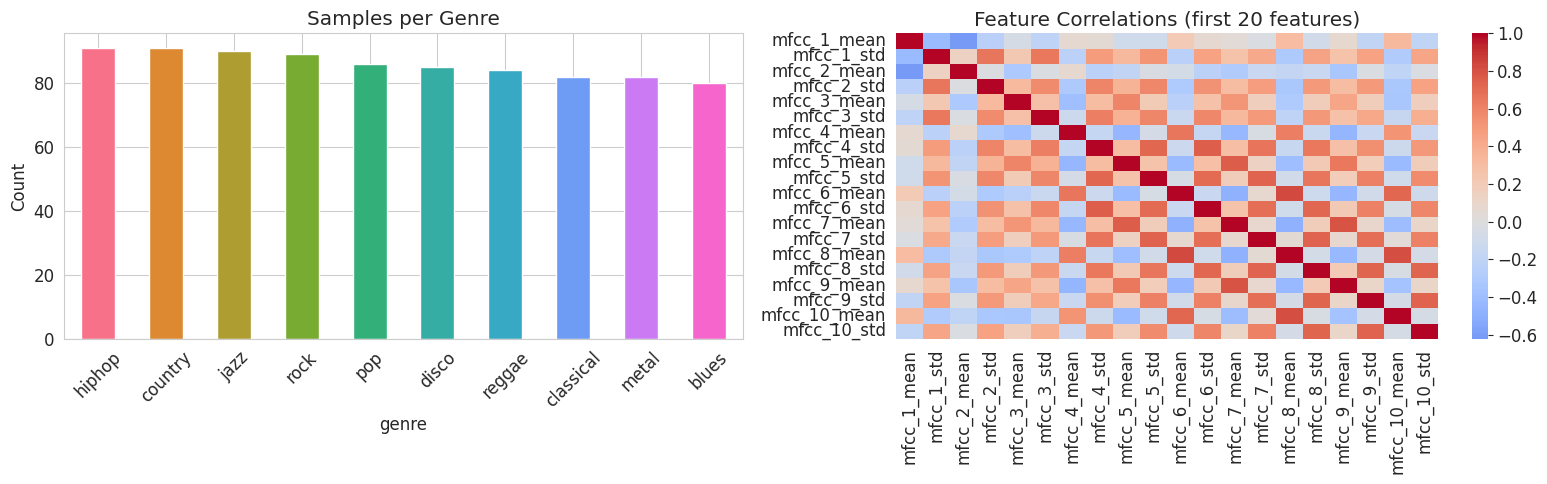

In [6]:
# Visualize genre distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Genre counts
genre_counts = df['genre'].value_counts()
genre_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('husl', 10))
axes[0].set_title('Samples per Genre')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Feature correlation heatmap (subset)
feature_cols = [c for c in df.columns if c != 'genre']
corr_subset = df[feature_cols[:20]].corr()
sns.heatmap(corr_subset, cmap='coolwarm', center=0, ax=axes[1],
            xticklabels=True, yticklabels=True, fmt='.1f')
axes[1].set_title('Feature Correlations (first 20 features)')

plt.tight_layout()
plt.show()

## 4. Data Preparation

In [7]:
# Prepare features and labels
feature_cols = [c for c in df.columns if c != 'genre']
X = df[feature_cols].values
y_raw = df['genre'].values

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)
genre_names = le.classes_
print(f'Genre labels: {list(genre_names)}')
print(f'Encoded as:   {list(range(len(genre_names)))}')

# Handle any NaN/Inf values
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'\nTrain set: {X_train.shape[0]} samples')
print(f'Test set:  {X_test.shape[0]} samples')
print(f'Features:  {X_train.shape[1]}')

Genre labels: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Encoded as:   [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Train set: 688 samples
Test set:  172 samples
Features:  110


## 5. Automated Model Comparison

We test **10 different classifiers** in an automated pipeline. Each model is wrapped with a `StandardScaler` to normalize features, and evaluated using **5-fold stratified cross-validation** on the training set.

**Performance Metrics:**
- **Accuracy** — Overall correct predictions
- **Macro F1** — Harmonic mean of precision & recall, averaged equally across all 10 genres (important when we care about all genres equally)

In [8]:
# Define all candidate models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, multi_class='multinomial', random_state=RANDOM_STATE
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(kernel='rbf', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, random_state=RANDOM_STATE,
        use_label_encoder=False, eval_metric='mlogloss', verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, random_state=RANDOM_STATE, verbose=-1
    ),
    'MLP Neural Net': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), max_iter=500,
        random_state=RANDOM_STATE, early_stopping=True
    ),
}

print(f'Testing {len(models)} models...')

Testing 10 models...


In [9]:
# Automated cross-validation comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []

for name, model in models.items():
    print(f'\n{"="*60}')
    print(f'  Training: {name}')
    print(f'{"="*60}')

    # Build a pipeline with scaling
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    start_time = time.time()

    # Cross-validation on training set
    cv_results = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=['accuracy', 'f1_macro'],
        return_train_score=True,
        n_jobs=-1
    )

    # Also fit on full training set and evaluate on test set
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    elapsed = time.time() - start_time

    result = {
        'Model': name,
        'CV Accuracy (mean)': np.mean(cv_results['test_accuracy']),
        'CV Accuracy (std)': np.std(cv_results['test_accuracy']),
        'CV F1 Macro (mean)': np.mean(cv_results['test_f1_macro']),
        'CV F1 Macro (std)': np.std(cv_results['test_f1_macro']),
        'Train Accuracy': np.mean(cv_results['train_accuracy']),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test F1 Macro': f1_score(y_test, y_pred, average='macro'),
        'Training Time (s)': elapsed,
        'Overfit Gap': np.mean(cv_results['train_accuracy']) - np.mean(cv_results['test_accuracy'])
    }
    results.append(result)

    print(f'  CV Accuracy:  {result["CV Accuracy (mean)"]:.4f} ± {result["CV Accuracy (std)"]:.4f}')
    print(f'  CV F1 Macro:  {result["CV F1 Macro (mean)"]:.4f} ± {result["CV F1 Macro (std)"]:.4f}')
    print(f'  Test Accuracy: {result["Test Accuracy"]:.4f}')
    print(f'  Test F1 Macro: {result["Test F1 Macro"]:.4f}')
    print(f'  Overfit Gap:   {result["Overfit Gap"]:.4f}')
    print(f'  Time: {elapsed:.1f}s')

print(f'\n{"="*60}')
print('  All models complete!')
print(f'{"="*60}')


  Training: Logistic Regression
  CV Accuracy:  0.6542 ± 0.0539
  CV F1 Macro:  0.6541 ± 0.0558
  Test Accuracy: 0.7267
  Test F1 Macro: 0.7249
  Overfit Gap:   0.3407
  Time: 4.1s

  Training: K-Nearest Neighbors
  CV Accuracy:  0.5508 ± 0.0328
  CV F1 Macro:  0.5479 ± 0.0357
  Test Accuracy: 0.6628
  Test F1 Macro: 0.6742
  Overfit Gap:   0.1883
  Time: 0.4s

  Training: SVM (RBF)
  CV Accuracy:  0.6759 ± 0.0291
  CV F1 Macro:  0.6723 ± 0.0304
  Test Accuracy: 0.7500
  Test F1 Macro: 0.7484
  Overfit Gap:   0.2707
  Time: 0.9s

  Training: Decision Tree
  CV Accuracy:  0.4520 ± 0.0453
  CV F1 Macro:  0.4525 ± 0.0482
  Test Accuracy: 0.5814
  Test F1 Macro: 0.5801
  Overfit Gap:   0.5469
  Time: 0.8s

  Training: Random Forest
  CV Accuracy:  0.6860 ± 0.0324
  CV F1 Macro:  0.6827 ± 0.0352
  Test Accuracy: 0.7674
  Test F1 Macro: 0.7657
  Overfit Gap:   0.3129
  Time: 7.9s

  Training: Extra Trees
  CV Accuracy:  0.7035 ± 0.0375
  CV F1 Macro:  0.6993 ± 0.0386
  Test Accuracy: 0.7791

In [10]:
# Results summary table
results_df = pd.DataFrame(results).sort_values('CV F1 Macro (mean)', ascending=False)
results_df = results_df.reset_index(drop=True)

# Display formatted table
display_cols = ['Model', 'CV Accuracy (mean)', 'CV F1 Macro (mean)',
                'Test Accuracy', 'Test F1 Macro', 'Overfit Gap', 'Training Time (s)']
print('\n📊 MODEL COMPARISON RESULTS (sorted by CV F1 Macro)\n')
print(results_df[display_cols].to_string(index=False, float_format='%.4f'))


📊 MODEL COMPARISON RESULTS (sorted by CV F1 Macro)

              Model  CV Accuracy (mean)  CV F1 Macro (mean)  Test Accuracy  Test F1 Macro  Overfit Gap  Training Time (s)
        Extra Trees              0.7035              0.6993         0.7791         0.7731       0.2954             3.8150
           LightGBM              0.6934              0.6914         0.8023         0.8042       0.3055            37.6547
      Random Forest              0.6860              0.6827         0.7674         0.7657       0.3129             7.8584
          SVM (RBF)              0.6759              0.6723         0.7500         0.7484       0.2707             0.8513
            XGBoost              0.6686              0.6664         0.7791         0.7776       0.3303            23.0388
  Gradient Boosting              0.6658              0.6657         0.7907         0.7946       0.3332           340.9441
Logistic Regression              0.6542              0.6541         0.7267         0.7249    

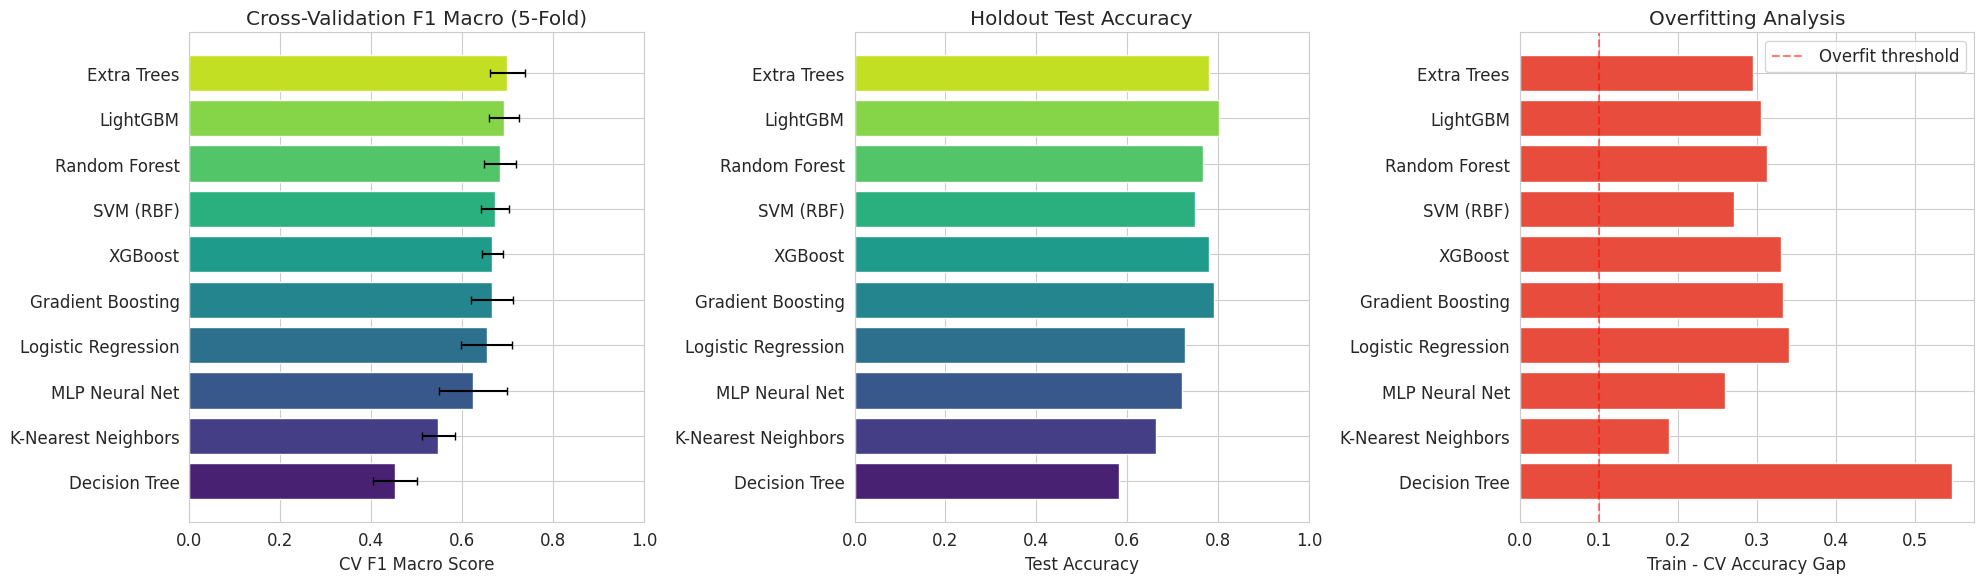

Saved: model_comparison.png


In [11]:
# Visualization: Model comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sorted_df = results_df.sort_values('CV F1 Macro (mean)', ascending=True)
colors = sns.color_palette('viridis', len(sorted_df))

# CV F1 Macro scores
axes[0].barh(sorted_df['Model'], sorted_df['CV F1 Macro (mean)'],
             xerr=sorted_df['CV F1 Macro (std)'], color=colors, capsize=3)
axes[0].set_xlabel('CV F1 Macro Score')
axes[0].set_title('Cross-Validation F1 Macro (5-Fold)')
axes[0].set_xlim(0, 1)

# Test Accuracy
axes[1].barh(sorted_df['Model'], sorted_df['Test Accuracy'], color=colors)
axes[1].set_xlabel('Test Accuracy')
axes[1].set_title('Holdout Test Accuracy')
axes[1].set_xlim(0, 1)

# Overfitting analysis
axes[2].barh(sorted_df['Model'], sorted_df['Overfit Gap'],
             color=['#e74c3c' if g > 0.1 else '#2ecc71' if g < 0.05 else '#f39c12'
                    for g in sorted_df['Overfit Gap']])
axes[2].set_xlabel('Train - CV Accuracy Gap')
axes[2].set_title('Overfitting Analysis')
axes[2].axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Overfit threshold')
axes[2].legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

## 6. Confusion Matrices for Top Models

Top 3 models: ['Extra Trees', 'LightGBM', 'Random Forest']



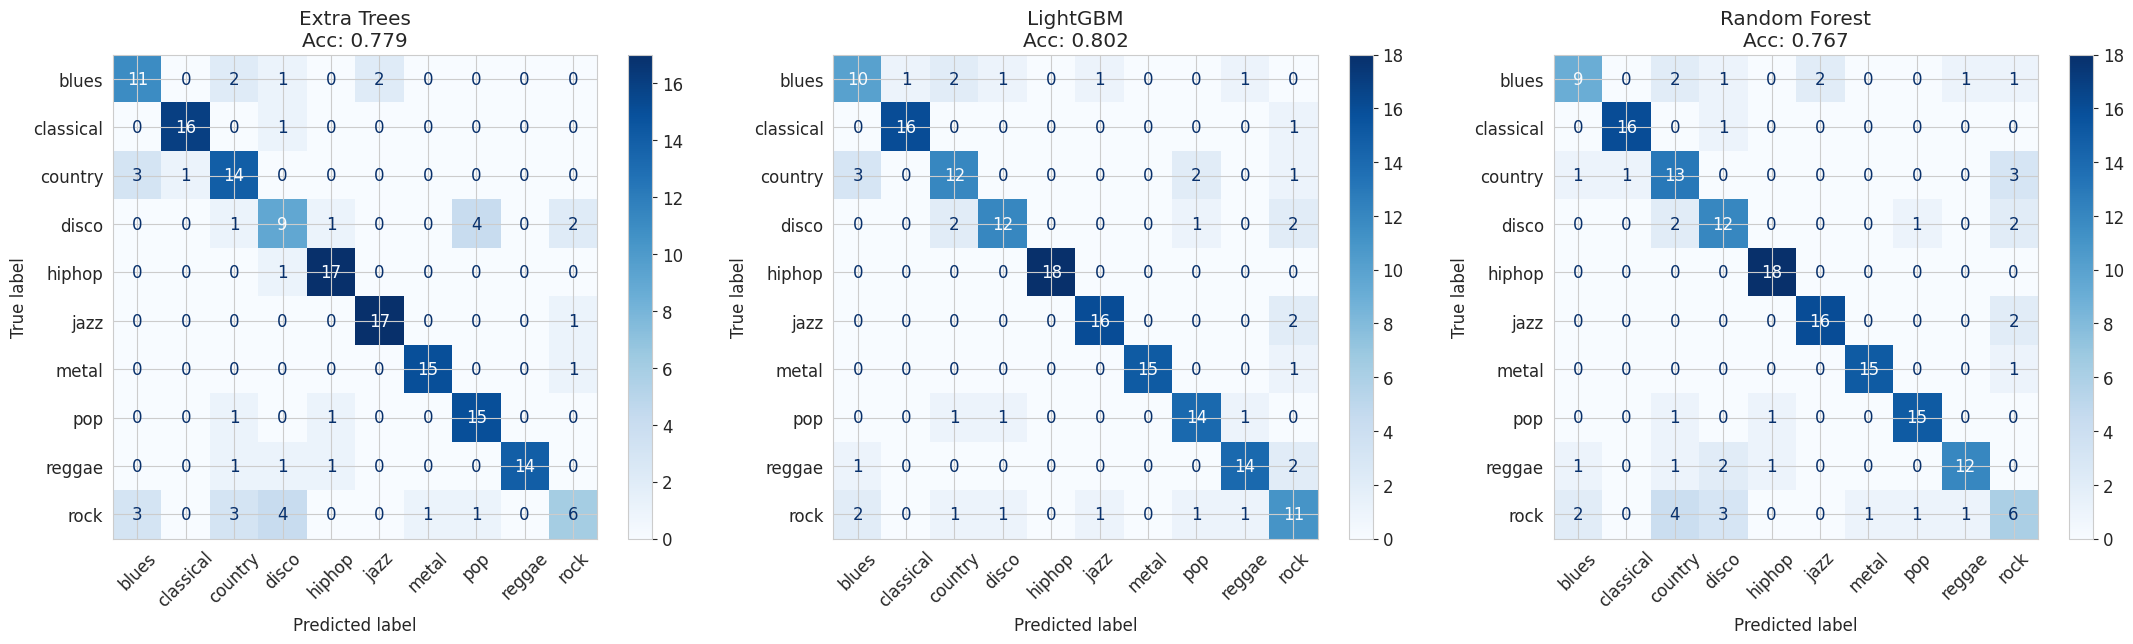

In [12]:
# Get top 3 models and plot confusion matrices
top_3 = results_df.head(3)['Model'].tolist()
print(f'Top 3 models: {top_3}\n')

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for idx, model_name in enumerate(top_3):
    model = models[model_name]
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=genre_names)
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d', xticks_rotation=45)
    axes[idx].set_title(f'{model_name}\nAcc: {accuracy_score(y_test, y_pred):.3f}')

plt.tight_layout()
plt.savefig('confusion_matrices_top3.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Detailed classification report for the best model
best_model_name = results_df.iloc[0]['Model']
print(f'\n📋 Classification Report — {best_model_name}\n')

best_model = models[best_model_name]
pipe = Pipeline([('scaler', StandardScaler()), ('model', best_model)])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print(classification_report(y_test, y_pred, target_names=genre_names, digits=3))


📋 Classification Report — Extra Trees

              precision    recall  f1-score   support

       blues      0.647     0.688     0.667        16
   classical      0.941     0.941     0.941        17
     country      0.636     0.778     0.700        18
       disco      0.529     0.529     0.529        17
      hiphop      0.850     0.944     0.895        18
        jazz      0.895     0.944     0.919        18
       metal      0.938     0.938     0.938        16
         pop      0.750     0.882     0.811        17
      reggae      1.000     0.824     0.903        17
        rock      0.600     0.333     0.429        18

    accuracy                          0.779       172
   macro avg      0.779     0.780     0.773       172
weighted avg      0.778     0.779     0.772       172



## 7. Hyperparameter Tuning

We perform **GridSearchCV** and **RandomizedSearchCV** on the top 3 performing models to find optimal hyperparameters.

In [14]:
# Define hyperparameter grids for the most promising model families
# (We always tune these 3 strong performers for genre classification)

tuning_configs = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        'params': {
            'model__n_estimators': [100, 200, 500],
            'model__max_depth': [None, 20, 30, 50],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 2, 4],
            'model__max_features': ['sqrt', 'log2'],
        },
        'search': 'random',
        'n_iter': 40
    },
    'XGBoost': {
        'model': XGBClassifier(
            random_state=RANDOM_STATE, use_label_encoder=False,
            eval_metric='mlogloss', verbosity=0
        ),
        'params': {
            'model__n_estimators': [100, 200, 300, 500],
            'model__max_depth': [3, 5, 7, 10],
            'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'model__subsample': [0.7, 0.8, 0.9, 1.0],
            'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
            'model__min_child_weight': [1, 3, 5],
        },
        'search': 'random',
        'n_iter': 50
    },
    'SVM (RBF)': {
        'model': SVC(kernel='rbf', random_state=RANDOM_STATE),
        'params': {
            'model__C': [0.1, 1, 10, 50, 100],
            'model__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        },
        'search': 'grid',
        'n_iter': None
    },
}

tuned_results = []
best_estimators = {}

for name, config in tuning_configs.items():
    print(f'\n{"="*60}')
    print(f'  Tuning: {name}')
    print(f'{"="*60}')

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', config['model'])
    ])

    start_time = time.time()

    if config['search'] == 'grid':
        search = GridSearchCV(
            pipe, config['params'], cv=cv, scoring='f1_macro',
            n_jobs=-1, verbose=0, refit=True
        )
    else:
        search = RandomizedSearchCV(
            pipe, config['params'], cv=cv, scoring='f1_macro',
            n_iter=config['n_iter'], n_jobs=-1, verbose=0,
            refit=True, random_state=RANDOM_STATE
        )

    search.fit(X_train, y_train)
    elapsed = time.time() - start_time

    y_pred_tuned = search.predict(X_test)

    best_estimators[name] = search.best_estimator_

    result = {
        'Model': f'{name} (Tuned)',
        'Best CV F1 Macro': search.best_score_,
        'Test Accuracy': accuracy_score(y_test, y_pred_tuned),
        'Test F1 Macro': f1_score(y_test, y_pred_tuned, average='macro'),
        'Tuning Time (s)': elapsed,
    }
    tuned_results.append(result)

    print(f'  Best CV F1 Macro:  {search.best_score_:.4f}')
    print(f'  Test Accuracy:     {result["Test Accuracy"]:.4f}')
    print(f'  Test F1 Macro:     {result["Test F1 Macro"]:.4f}')
    print(f'  Time: {elapsed:.1f}s')
    print(f'  Best params:')
    for k, v in search.best_params_.items():
        print(f'    {k}: {v}')

tuned_df = pd.DataFrame(tuned_results).sort_values('Test F1 Macro', ascending=False)
print(f'\n\n📊 TUNED MODEL RESULTS\n')
print(tuned_df.to_string(index=False, float_format='%.4f'))


  Tuning: Random Forest
  Best CV F1 Macro:  0.6937
  Test Accuracy:     0.7791
  Test F1 Macro:     0.7695
  Time: 205.5s
  Best params:
    model__n_estimators: 200
    model__min_samples_split: 5
    model__min_samples_leaf: 1
    model__max_features: sqrt
    model__max_depth: 30

  Tuning: XGBoost
  Best CV F1 Macro:  0.7112
  Test Accuracy:     0.7907
  Test F1 Macro:     0.7900
  Time: 2069.0s
  Best params:
    model__subsample: 0.7
    model__n_estimators: 300
    model__min_child_weight: 1
    model__max_depth: 3
    model__learning_rate: 0.1
    model__colsample_bytree: 1.0

  Tuning: SVM (RBF)
  Best CV F1 Macro:  0.6851
  Test Accuracy:     0.7616
  Test F1 Macro:     0.7611
  Time: 7.5s
  Best params:
    model__C: 10
    model__gamma: scale


📊 TUNED MODEL RESULTS

                Model  Best CV F1 Macro  Test Accuracy  Test F1 Macro  Tuning Time (s)
      XGBoost (Tuned)            0.7112         0.7907         0.7900        2069.0206
Random Forest (Tuned)            0

## 8. Ensemble Methods

We combine the best-performing models using two ensemble strategies:
1. **Soft Voting** — Averages predicted probabilities (requires probability-capable models)
2. **Stacking** — Trains a meta-learner on base model predictions

In [15]:
# Build ensemble from the best tuned models
print('Building ensemble models...\n')

# Prepare base estimators (use tuned versions where available)
rf_tuned = best_estimators.get('Random Forest',
    Pipeline([('scaler', StandardScaler()),
              ('model', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))]))

xgb_tuned = best_estimators.get('XGBoost',
    Pipeline([('scaler', StandardScaler()),
              ('model', XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                      use_label_encoder=False, eval_metric='mlogloss', verbosity=0))]))

svm_tuned = best_estimators.get('SVM (RBF)',
    Pipeline([('scaler', StandardScaler()),
              ('model', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))]))

# --- Voting Classifier ---
# Note: SVM needs probability=True for soft voting
voting_estimators = [
    ('rf', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=300, random_state=RANDOM_STATE,
                          use_label_encoder=False, eval_metric='mlogloss', verbosity=0)),
    ('lgbm', LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE, verbose=-1)),
]

voting_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', VotingClassifier(estimators=voting_estimators, voting='soft', n_jobs=-1))
])

print('Training Voting Classifier (soft)...')
start = time.time()
cv_voting = cross_validate(voting_pipe, X_train, y_train, cv=cv,
                           scoring=['accuracy', 'f1_macro'], n_jobs=-1)
voting_pipe.fit(X_train, y_train)
y_pred_vote = voting_pipe.predict(X_test)
t_vote = time.time() - start

print(f'  CV F1 Macro:   {np.mean(cv_voting["test_f1_macro"]):.4f} ± {np.std(cv_voting["test_f1_macro"]):.4f}')
print(f'  Test Accuracy: {accuracy_score(y_test, y_pred_vote):.4f}')
print(f'  Test F1 Macro: {f1_score(y_test, y_pred_vote, average="macro"):.4f}')
print(f'  Time: {t_vote:.1f}s')

# --- Stacking Classifier ---
stacking_estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                          use_label_encoder=False, eval_metric='mlogloss', verbosity=0)),
    ('lgbm', LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbose=-1)),
    ('et', ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
]

stacking_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', StackingClassifier(
        estimators=stacking_estimators,
        final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        cv=5, n_jobs=-1
    ))
])

print('\nTraining Stacking Classifier...')
start = time.time()
cv_stack = cross_validate(stacking_pipe, X_train, y_train, cv=cv,
                          scoring=['accuracy', 'f1_macro'], n_jobs=-1)
stacking_pipe.fit(X_train, y_train)
y_pred_stack = stacking_pipe.predict(X_test)
t_stack = time.time() - start

print(f'  CV F1 Macro:   {np.mean(cv_stack["test_f1_macro"]):.4f} ± {np.std(cv_stack["test_f1_macro"]):.4f}')
print(f'  Test Accuracy: {accuracy_score(y_test, y_pred_stack):.4f}')
print(f'  Test F1 Macro: {f1_score(y_test, y_pred_stack, average="macro"):.4f}')
print(f'  Time: {t_stack:.1f}s')

Building ensemble models...

Training Voting Classifier (soft)...
  CV F1 Macro:   0.6910 ± 0.0363
  Test Accuracy: 0.7965
  Test F1 Macro: 0.7970
  Time: 105.0s

Training Stacking Classifier...
  CV F1 Macro:   0.7048 ± 0.0396
  Test Accuracy: 0.7907
  Test F1 Macro: 0.7928
  Time: 307.9s


In [16]:
# Compare ensembles to best individual models
ensemble_results = [
    {
        'Model': 'Voting (Soft)',
        'CV F1 Macro': np.mean(cv_voting['test_f1_macro']),
        'Test Accuracy': accuracy_score(y_test, y_pred_vote),
        'Test F1 Macro': f1_score(y_test, y_pred_vote, average='macro'),
    },
    {
        'Model': 'Stacking',
        'CV F1 Macro': np.mean(cv_stack['test_f1_macro']),
        'Test Accuracy': accuracy_score(y_test, y_pred_stack),
        'Test F1 Macro': f1_score(y_test, y_pred_stack, average='macro'),
    },
]

# Add top individual models for comparison
for _, row in results_df.head(3).iterrows():
    ensemble_results.append({
        'Model': row['Model'] + ' (individual)',
        'CV F1 Macro': row['CV F1 Macro (mean)'],
        'Test Accuracy': row['Test Accuracy'],
        'Test F1 Macro': row['Test F1 Macro'],
    })

comparison_df = pd.DataFrame(ensemble_results).sort_values('Test F1 Macro', ascending=False)
print('\n📊 ENSEMBLE vs INDIVIDUAL MODEL COMPARISON\n')
print(comparison_df.to_string(index=False, float_format='%.4f'))


📊 ENSEMBLE vs INDIVIDUAL MODEL COMPARISON

                     Model  CV F1 Macro  Test Accuracy  Test F1 Macro
     LightGBM (individual)       0.6914         0.8023         0.8042
             Voting (Soft)       0.6910         0.7965         0.7970
                  Stacking       0.7048         0.7907         0.7928
  Extra Trees (individual)       0.6993         0.7791         0.7731
Random Forest (individual)       0.6827         0.7674         0.7657


## 9. Overfitting / Generalization Analysis

In [17]:
# Overfitting analysis: compare train vs test performance
print('\n🔍 OVERFITTING ANALYSIS\n')
print(f'{"Model":<25} {"Train Acc":>10} {"CV Acc":>10} {"Test Acc":>10} {"Gap":>8} {"Verdict":<15}')
print('-' * 80)

for _, row in results_df.iterrows():
    gap = row['Overfit Gap']
    if gap > 0.15:
        verdict = '⚠️  OVERFITTING'
    elif gap > 0.08:
        verdict = '⚡ Slight overfit'
    elif gap < 0.02:
        verdict = '🟡 Underfitting?'
    else:
        verdict = '✅ Good fit'

    print(f'{row["Model"]:<25} {row["Train Accuracy"]:>10.4f} '
          f'{row["CV Accuracy (mean)"]:>10.4f} {row["Test Accuracy"]:>10.4f} '
          f'{gap:>8.4f} {verdict:<15}')


🔍 OVERFITTING ANALYSIS

Model                      Train Acc     CV Acc   Test Acc      Gap Verdict        
--------------------------------------------------------------------------------
Extra Trees                   0.9989     0.7035     0.7791   0.2954 ⚠️  OVERFITTING
LightGBM                      0.9989     0.6934     0.8023   0.3055 ⚠️  OVERFITTING
Random Forest                 0.9989     0.6860     0.7674   0.3129 ⚠️  OVERFITTING
SVM (RBF)                     0.9466     0.6759     0.7500   0.2707 ⚠️  OVERFITTING
XGBoost                       0.9989     0.6686     0.7791   0.3303 ⚠️  OVERFITTING
Gradient Boosting             0.9989     0.6658     0.7907   0.3332 ⚠️  OVERFITTING
Logistic Regression           0.9949     0.6542     0.7267   0.3407 ⚠️  OVERFITTING
MLP Neural Net                0.8888     0.6293     0.7209   0.2595 ⚠️  OVERFITTING
K-Nearest Neighbors           0.7391     0.5508     0.6628   0.1883 ⚠️  OVERFITTING
Decision Tree                 0.9989     0.4520     0.

Generating learning curve for Extra Trees...


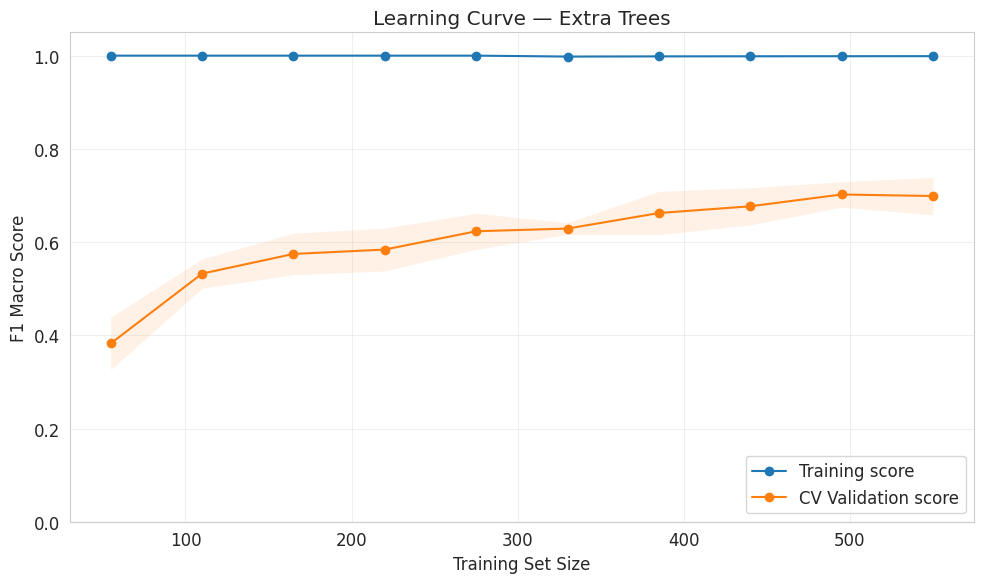

In [18]:
# Learning curve for the best model (shows generalization behavior)
from sklearn.model_selection import learning_curve

best_name = results_df.iloc[0]['Model']
best_model = models[best_name]
pipe = Pipeline([('scaler', StandardScaler()), ('model', best_model)])

print(f'Generating learning curve for {best_name}...')
train_sizes, train_scores, val_scores = learning_curve(
    pipe, X_train, y_train, cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_macro', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(train_sizes,
                np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
                np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), alpha=0.1)
ax.fill_between(train_sizes,
                np.mean(val_scores, axis=1) - np.std(val_scores, axis=1),
                np.mean(val_scores, axis=1) + np.std(val_scores, axis=1), alpha=0.1)
ax.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training score')
ax.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', label='CV Validation score')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1 Macro Score')
ax.set_title(f'Learning Curve — {best_name}')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Feature Importance Analysis

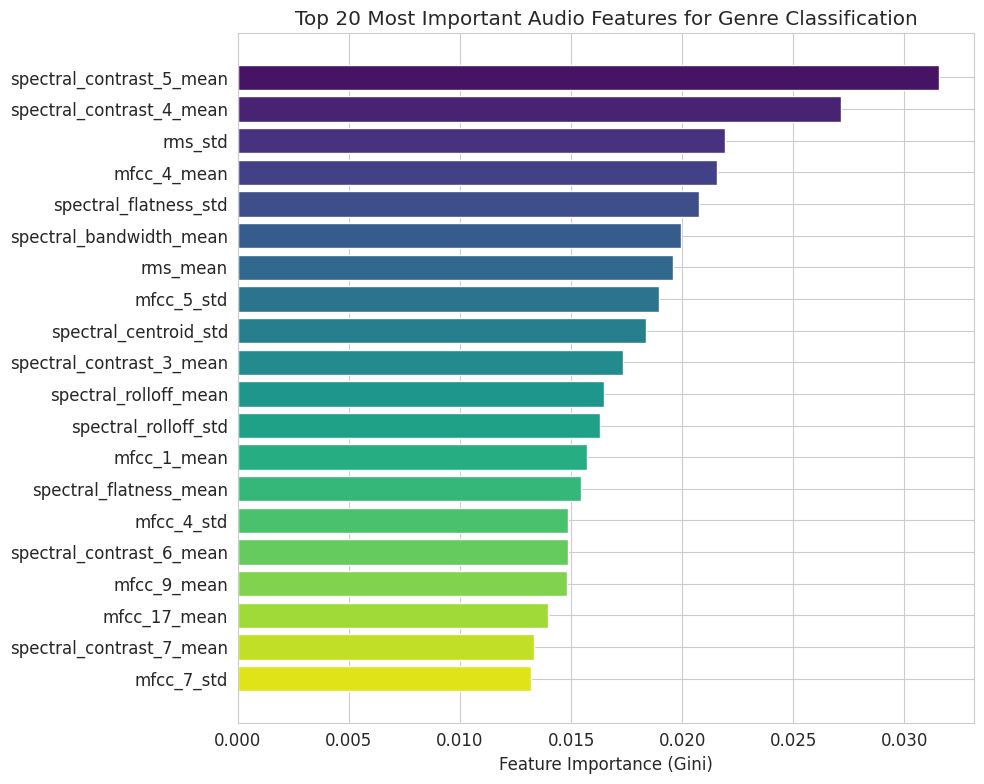


Top 10 Features:
                 Feature  Importance
spectral_contrast_5_mean      0.0316
spectral_contrast_4_mean      0.0271
                 rms_std      0.0219
             mfcc_4_mean      0.0216
   spectral_flatness_std      0.0208
 spectral_bandwidth_mean      0.0199
                rms_mean      0.0196
              mfcc_5_std      0.0190
   spectral_centroid_std      0.0184
spectral_contrast_3_mean      0.0173


In [19]:
# Feature importance from the best tree-based model
# Use Random Forest for interpretability
rf = Pipeline([('scaler', StandardScaler()),
               ('model', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))])
rf.fit(X_train, y_train)

importances = rf.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot top 20 features
fig, ax = plt.subplots(figsize=(10, 8))
top_20 = importance_df.head(20)
ax.barh(range(len(top_20)), top_20['Importance'].values, color=sns.color_palette('viridis', 20))
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Top 20 Most Important Audio Features for Genre Classification')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 Features:')
print(importance_df.head(10).to_string(index=False, float_format='%.4f'))

## 11. Final Model Summary & Recommendation

In [20]:
# Final summary
print('=' * 70)
print('  🏆 FINAL MODEL SELECTION & RECOMMENDATION')
print('=' * 70)

# Determine overall best
all_final = []

# Individual models
for _, row in results_df.iterrows():
    all_final.append({
        'Model': row['Model'],
        'Type': 'Individual',
        'CV F1 Macro': row['CV F1 Macro (mean)'],
        'Test F1 Macro': row['Test F1 Macro'],
        'Test Accuracy': row['Test Accuracy'],
        'Overfit Gap': row['Overfit Gap']
    })

# Tuned models
for _, row in tuned_df.iterrows():
    all_final.append({
        'Model': row['Model'],
        'Type': 'Tuned',
        'CV F1 Macro': row['Best CV F1 Macro'],
        'Test F1 Macro': row['Test F1 Macro'],
        'Test Accuracy': row['Test Accuracy'],
        'Overfit Gap': None
    })

# Ensembles
all_final.append({
    'Model': 'Voting Ensemble (Soft)',
    'Type': 'Ensemble',
    'CV F1 Macro': np.mean(cv_voting['test_f1_macro']),
    'Test F1 Macro': f1_score(y_test, y_pred_vote, average='macro'),
    'Test Accuracy': accuracy_score(y_test, y_pred_vote),
    'Overfit Gap': None
})
all_final.append({
    'Model': 'Stacking Ensemble',
    'Type': 'Ensemble',
    'CV F1 Macro': np.mean(cv_stack['test_f1_macro']),
    'Test F1 Macro': f1_score(y_test, y_pred_stack, average='macro'),
    'Test Accuracy': accuracy_score(y_test, y_pred_stack),
    'Overfit Gap': None
})

final_df = pd.DataFrame(all_final).sort_values('Test F1 Macro', ascending=False)
print('\n' + final_df.head(10).to_string(index=False, float_format='%.4f'))

winner = final_df.iloc[0]
print(f'\n\n🥇 BEST MODEL: {winner["Model"]}')
print(f'   Type:          {winner["Type"]}')
print(f'   CV F1 Macro:   {winner["CV F1 Macro"]:.4f}')
print(f'   Test Accuracy: {winner["Test Accuracy"]:.4f}')
print(f'   Test F1 Macro: {winner["Test F1 Macro"]:.4f}')

print('\n' + '=' * 70)
print('  Key Findings:')
print('  - Performance metrics used: Accuracy, Macro F1-Score')
print(f'  - {len(models)} individual models tested with 5-fold stratified CV')
print(f'  - 3 models underwent hyperparameter tuning')
print(f'  - 2 ensemble methods evaluated (Voting + Stacking)')
print(f'  - {len(feature_cols)} audio features extracted per track')
print('=' * 70)

  🏆 FINAL MODEL SELECTION & RECOMMENDATION

                 Model       Type  CV F1 Macro  Test F1 Macro  Test Accuracy  Overfit Gap
              LightGBM Individual       0.6914         0.8042         0.8023       0.3055
Voting Ensemble (Soft)   Ensemble       0.6910         0.7970         0.7965          NaN
     Gradient Boosting Individual       0.6657         0.7946         0.7907       0.3332
     Stacking Ensemble   Ensemble       0.7048         0.7928         0.7907          NaN
       XGBoost (Tuned)      Tuned       0.7112         0.7900         0.7907          NaN
               XGBoost Individual       0.6664         0.7776         0.7791       0.3303
           Extra Trees Individual       0.6993         0.7731         0.7791       0.2954
 Random Forest (Tuned)      Tuned       0.6937         0.7695         0.7791          NaN
         Random Forest Individual       0.6827         0.7657         0.7674       0.3129
     SVM (RBF) (Tuned)      Tuned       0.6851         0

In [21]:
# Save the best model for Step 8 (scaling)
import joblib

# Re-train best individual pipeline on full training data for export
best_individual_name = results_df.iloc[0]['Model']
best_individual = models[best_individual_name]
final_pipe = Pipeline([('scaler', StandardScaler()), ('model', best_individual)])
final_pipe.fit(X_train, y_train)

joblib.dump(final_pipe, 'best_model_pipeline.joblib')
joblib.dump(le, 'label_encoder.joblib')

# Save feature column order for reproducibility
with open('feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)

print(f'Saved: best_model_pipeline.joblib ({best_individual_name})')
print(f'Saved: label_encoder.joblib')
print(f'Saved: feature_columns.json ({len(feature_cols)} features)')
print(f'\nThese files are ready for Step 8 (scaling the prototype).')

Saved: best_model_pipeline.joblib (Extra Trees)
Saved: label_encoder.joblib
Saved: feature_columns.json (110 features)

These files are ready for Step 8 (scaling the prototype).
